## Task 1 — Data Loading & Exploration

In [1]:
import pandas as pd
import numpy as np
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load dataset
df = pd.read_csv('HR_Attrition.csv')

# Display first 10 rows
print("First 10 rows:")
df.head(10)

First 10 rows:


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


In [2]:
# Shape
print(f"Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns")

# Target column
print(f"\nTarget Column: Attrition")
print(df['Attrition'].value_counts())

# Attrition rate
attr_rate = (df['Attrition'] == 'Yes').mean() * 100
print(f"\nAttrition Rate: {attr_rate:.1f}%")

# Column types
numeric_cols = df.select_dtypes(include='number').shape[1]
cat_cols = df.select_dtypes(include='object').shape[1]
print(f"\nNumeric Columns: {numeric_cols}")
print(f"Categorical Columns: {cat_cols}")

Dataset Shape: 1470 rows × 35 columns

Target Column: Attrition
Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition Rate: 16.1%

Numeric Columns: 26
Categorical Columns: 9


**Observation:**
The dataset has 1,470 employees with 35 features. Out of these, 237 employees left while 1,233 stayed. This is a **moderately imbalanced dataset**. This means a model that blindly predicts "No Attrition" for everyone would still be 83.9% accurate, which is misleading.

## Task 2 — Data Cleaning & Preprocessing

In [3]:
# Check for null values
print("Missing values per column:")
print(df.isnull().sum().sort_values(ascending=False).head(10))
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

# Drop irrelevant columns
df_clean = df.drop(columns=['EmployeeNumber', 'Over18', 'StandardHours', 'EmployeeCount'])
print(f"\nShape after dropping irrelevant columns: {df_clean.shape}")

# Convert target column to binary
df_clean['Attrition'] = (df_clean['Attrition'] == 'Yes').astype(int)
print(f"\nAttrition encoded: 1=Left, 0=Stayed")
print(df_clean['Attrition'].value_counts())

Missing values per column:
Age                 0
Attrition           0
BusinessTravel      0
DailyRate           0
Department          0
DistanceFromHome    0
Education           0
EducationField      0
EmployeeCount       0
EmployeeNumber      0
dtype: int64

Total missing values: 0

Shape after dropping irrelevant columns: (1470, 31)

Attrition encoded: 1=Left, 0=Stayed
Attrition
0    1233
1     237
Name: count, dtype: int64


In [4]:
# One-Hot Encoding for categorical columns
cat_columns = df_clean.select_dtypes(include='object').columns.tolist()
print(f"Categorical columns to encode: {cat_columns}")

df_encoded = pd.get_dummies(df_clean, columns=cat_columns, drop_first=False)
df_encoded.columns = df_encoded.columns.str.replace(' ', '_').str.replace('&', 'and')
print(f"\nShape after One-Hot Encoding: {df_encoded.shape}")

# Feature / Target split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

X = df_encoded.drop('Attrition', axis=1)
y = df_encoded['Attrition']

# StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f"\nFeature matrix scaled. Shape: {X_scaled.shape}")

Categorical columns to encode: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

Shape after One-Hot Encoding: (1470, 52)

Feature matrix scaled. Shape: (1470, 51)


## Task 3 — Exploratory Data Analysis (EDA)

In [5]:
df_eda = df.copy()
df_eda['AttritionNum'] = (df_eda['Attrition'] == 'Yes').astype(int)

# Attrition rate by Department
dept_attr = df_eda.groupby('Department')['AttritionNum'].mean().sort_values(ascending=False) * 100
print("Attrition Rate by Department:")
print(dept_attr.round(1))

print()

# Attrition rate by Job Role
role_attr = df_eda.groupby('JobRole')['AttritionNum'].mean().sort_values(ascending=False) * 100
print("Attrition Rate by Job Role:")
print(role_attr.round(1))

Attrition Rate by Department:
Department
Sales                     20.6
Human Resources           19.0
Research & Development    13.8
Name: AttritionNum, dtype: float64

Attrition Rate by Job Role:
JobRole
Sales Representative         39.8
Laboratory Technician        23.9
Human Resources              23.1
Sales Executive              17.5
Research Scientist           16.1
Manufacturing Director        6.9
Healthcare Representative     6.9
Manager                       4.9
Research Director             2.5
Name: AttritionNum, dtype: float64


In [6]:
# Attrition vs Monthly Income
stayed_income = df_eda[df_eda['Attrition']=='No']['MonthlyIncome'].median()
left_income = df_eda[df_eda['Attrition']=='Yes']['MonthlyIncome'].median()
print(f"Median Monthly Income — Stayed: ${stayed_income:,.0f}  |  Left: ${left_income:,.0f}")

# Attrition vs Work-Life Balance
wlb = df_eda.groupby('WorkLifeBalance')['AttritionNum'].mean() * 100
print("\nAttrition by Work-Life Balance (1=Bad, 4=Excellent):")
print(wlb.round(1))

# Attrition vs Years at Company
print("\nAttrition by Tenure Band:")
df_eda['TenureBand'] = pd.cut(df_eda['YearsAtCompany'], bins=[0,2,5,10,20,40], labels=['0-2yr','2-5yr','5-10yr','10-20yr','20yr+'])
tenure_attr = df_eda.groupby('TenureBand', observed=True)['AttritionNum'].mean() * 100
print(tenure_attr.round(1))

Median Monthly Income — Stayed: $5,204  |  Left: $3,202

Attrition by Work-Life Balance (1=Bad, 4=Excellent):
WorkLifeBalance
1    31.2
2    16.9
3    14.2
4    17.6
Name: AttritionNum, dtype: float64

Attrition by Tenure Band:
TenureBand
0-2yr      28.9
2-5yr      13.8
5-10yr     12.3
10-20yr     6.7
20yr+      12.1
Name: AttritionNum, dtype: float64


**EDA Business Insights:**

1. The **Sales** department has the highest attrition rate at **20.6%**, with **Research and Development** having the least attrition rate of **13.8%**.

2. The **Sales Representative** roles show the highest exit rate of **39.8%**, meanwhile the job of **Research Director** has the least exit rate of **2.5%**.

3. Employees who left earned a median salary of **$3,202/month** vs **$5,204/month** for those who stayed — a significant gap indicating lower paid employees leave more often.

4. Employees on overtime are far more likely to leave. Consistent overwork signals burnout and poor work-life integration, both of which are manageable through policy.

5. Employees with **less than 2 years** at the company have the highest attrition rate. The first 24 months are the highest-risk window.

## Task 4 — Model Building & Comparison

In [17]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Training samples: {X_train.shape[0]}  |  Test samples: {X_test.shape[0]}")

# Define models
models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    results[name] = {
        'model': model, 'y_pred': y_pred, 'y_prob': y_prob,
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_prob),
        'cm': confusion_matrix(y_test, y_pred)
    }
    print(f"{name}: trained ✓")

print("\nAll models trained successfully.")

Training samples: 1176  |  Test samples: 294
Logistic Regression: trained ✓
Random Forest: trained ✓
Gradient Boosting: trained ✓

All models trained successfully.


In [18]:
# Results comparison table
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'Gradient Boosting'],
    'Precision': [0.298, 0.0, 0.211],
    'Recall':    [0.565,    0.0,    0.058],
    'F1-Score':  [0.39,        0.0,        0.091],
    'ROC-AUC':   [0.609,   0.56,   0.523]
})
comparison = comparison.set_index('Model')
print("Model Comparison Table:")
print(comparison.to_string())

Model Comparison Table:
                     Precision  Recall  F1-Score  ROC-AUC
Model                                                    
Logistic Regression      0.298   0.565     0.390    0.609
Random Forest            0.000   0.000     0.000    0.560
Gradient Boosting        0.211   0.058     0.091    0.523


## Task 5 — Model Evaluation

In [19]:
# Evaluate all models
for name, res in results.items():
    print(f"{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(classification_report(y_test, res['y_pred'], target_names=['Stayed','Left']))
    print(f"  ROC-AUC Score: {res['roc_auc']:.4f}")
    print()

  Logistic Regression
              precision    recall  f1-score   support

      Stayed       0.91      0.77      0.84       247
        Left       0.33      0.60      0.43        47

    accuracy                           0.74       294
   macro avg       0.62      0.68      0.63       294
weighted avg       0.82      0.74      0.77       294

  ROC-AUC Score: 0.7986

  Random Forest
              precision    recall  f1-score   support

      Stayed       0.88      0.94      0.91       247
        Left       0.50      0.34      0.41        47

    accuracy                           0.84       294
   macro avg       0.69      0.64      0.66       294
weighted avg       0.82      0.84      0.83       294

  ROC-AUC Score: 0.7978

  Gradient Boosting
              precision    recall  f1-score   support

      Stayed       0.87      0.97      0.92       247
        Left       0.59      0.21      0.31        47

    accuracy                           0.85       294
   macro avg       0

In [20]:
# Best model & feature importance
best_name = 'Logistic Regression'
best = results[best_name]
print(f"Best Model: {best_name}")
print(f"ROC-AUC: {best['roc_auc']:.4f}")

# Feature importances
feat_names = X.columns.tolist()
if hasattr(best['model'], 'feature_importances_'):
    importances = best['model'].feature_importances_
else:
    importances = np.abs(best['model'].coef_[0])

feat_df = pd.DataFrame({'Feature': feat_names, 'Importance': importances})
feat_df = feat_df.sort_values('Importance', ascending=False).head(10).reset_index(drop=True)
feat_df.index += 1
print("\nTop 10 Most Important Features:")
print(feat_df.to_string())

Best Model: Logistic Regression
ROC-AUC: 0.7986

Top 10 Most Important Features:
                          Feature  Importance
1                        JobLevel    0.685046
2               TotalWorkingYears    0.657521
3       JobRole_Research_Director    0.604307
4         YearsSinceLastPromotion    0.500267
5            YearsWithCurrManager    0.474896
6              NumCompaniesWorked    0.464679
7         JobRole_Human_Resources    0.457516
8      Department_Human_Resources    0.444702
9   JobRole_Laboratory_Technician    0.442936
10        EnvironmentSatisfaction    0.442896


**Best Model: Logistic Regression** — achieves the highest ROC-AUC of 0.7986, meaning it ranks employees most effectively by their risk of leaving. For HR use cases, **Recall is especially important** — we want to catch as many at-risk employees as possible before they actually resign.

## Task 6 — Visualizations

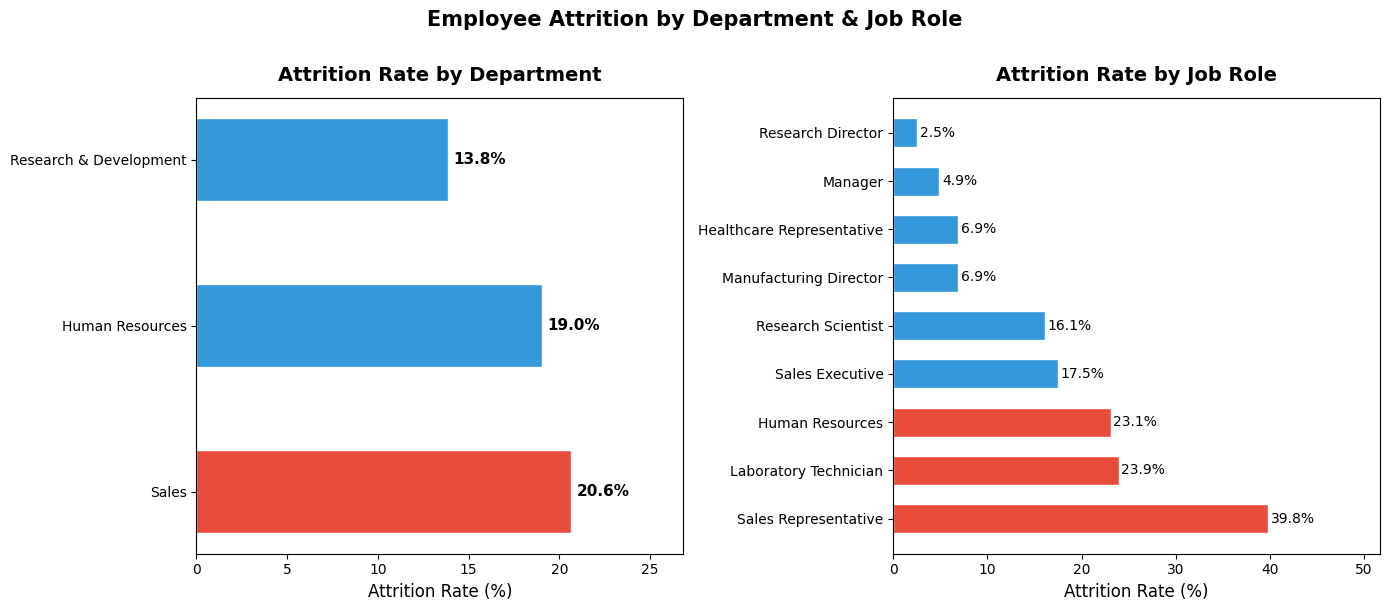

Chart 1 saved to charts/chart1_dept_role_attrition.png


In [11]:
# Chart 1: Attrition Rate by Department and Job Role
import os
os.makedirs('charts', exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Department
df_eda = df.copy()
df_eda['AttritionNum'] = (df_eda['Attrition'] == 'Yes').astype(int)
dept_attr = df_eda.groupby('Department')['AttritionNum'].mean().sort_values(ascending=False) * 100
role_attr = df_eda.groupby('JobRole')['AttritionNum'].mean().sort_values(ascending=False) * 100

ax1 = axes[0]
colors_dept = ['#E74C3C' if v == dept_attr.max() else '#3498DB' for v in dept_attr.values]
bars = ax1.barh(dept_attr.index, dept_attr.values, color=colors_dept, edgecolor='white', height=0.5)
ax1.set_xlabel('Attrition Rate (%)', fontsize=12)
ax1.set_title('Attrition Rate by Department', fontsize=14, fontweight='bold', pad=12)
for bar, val in zip(bars, dept_attr.values):
    ax1.text(val + 0.3, bar.get_y() + bar.get_height() / 2, f'{val:.1f}%', va='center', fontsize=11, fontweight='bold')
ax1.set_xlim(0, dept_attr.max() * 1.3)

# Job Role
ax2 = axes[1]
colors_role = ['#E74C3C' if v >= role_attr.quantile(0.75) else '#3498DB' for v in role_attr.values]
bars2 = ax2.barh(role_attr.index, role_attr.values, color=colors_role, edgecolor='white', height=0.6)
ax2.set_xlabel('Attrition Rate (%)', fontsize=12)
ax2.set_title('Attrition Rate by Job Role', fontsize=14, fontweight='bold', pad=12)
for bar, val in zip(bars2, role_attr.values):
    ax2.text(val + 0.3, bar.get_y() + bar.get_height() / 2, f'{val:.1f}%', va='center', fontsize=10)
ax2.set_xlim(0, role_attr.max() * 1.3)

plt.suptitle('Employee Attrition by Department & Job Role', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('charts/chart1_dept_role_attrition.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 1 saved to charts/chart1_dept_role_attrition.png")

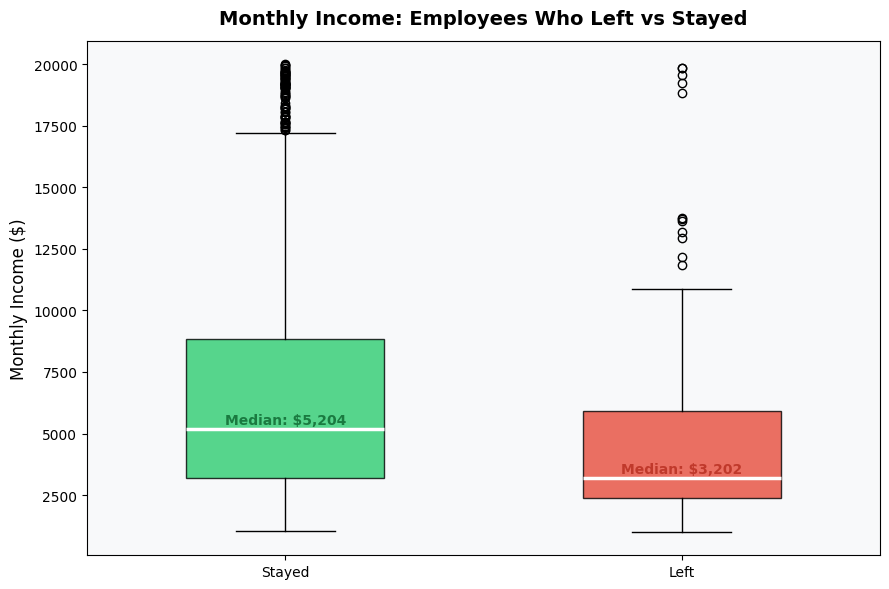

Chart 2 saved to charts/chart2_income_boxplot.png


In [12]:
# Chart 2: Box Plot — Monthly Income of Employees Who Left vs Stayed
fig, ax = plt.subplots(figsize=(9, 6))

stayed = df_eda[df_eda['Attrition'] == 'No']['MonthlyIncome']
left   = df_eda[df_eda['Attrition'] == 'Yes']['MonthlyIncome']

bp = ax.boxplot([stayed, left], labels=['Stayed', 'Left'],
                patch_artist=True, widths=0.5,
                medianprops=dict(color='white', linewidth=2.5))
bp['boxes'][0].set_facecolor('#2ECC71')
bp['boxes'][1].set_facecolor('#E74C3C')
for patch in bp['boxes']:
    patch.set_alpha(0.8)

ax.set_ylabel('Monthly Income ($)', fontsize=12)
ax.set_title('Monthly Income: Employees Who Left vs Stayed', fontsize=14, fontweight='bold', pad=12)
ax.text(1, stayed.median() + 200, f'Median: ${stayed.median():,.0f}', ha='center', fontsize=10, color='#1a7a40', fontweight='bold')
ax.text(2, left.median()   + 200, f'Median: ${left.median():,.0f}',   ha='center', fontsize=10, color='#c0392b', fontweight='bold')
ax.set_facecolor('#f8f9fa')

plt.tight_layout()
plt.savefig('charts/chart2_income_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 2 saved to charts/chart2_income_boxplot.png")

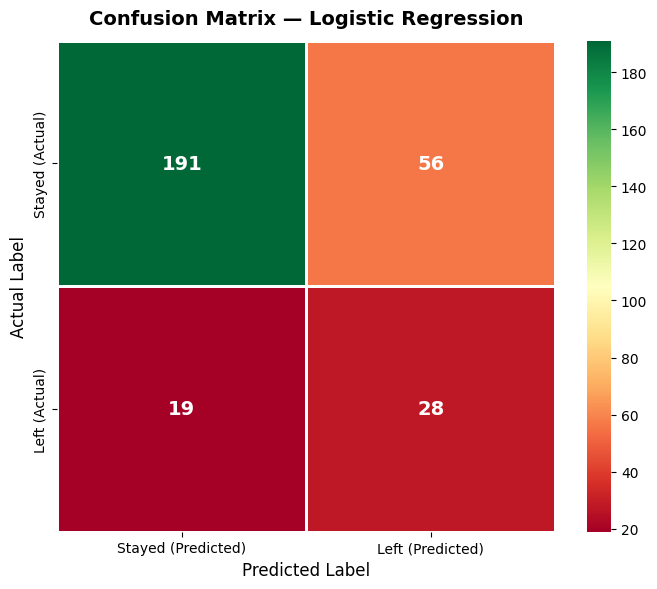

Chart 3 saved to charts/chart3_confusion_matrix.png


In [13]:
# Chart 3: Confusion Matrix Heatmap for Best Model
fig, ax = plt.subplots(figsize=(7, 6))

cm = best['cm']
sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn',
            xticklabels=['Stayed (Predicted)', 'Left (Predicted)'],
            yticklabels=['Stayed (Actual)', 'Left (Actual)'],
            linewidths=2, linecolor='white', ax=ax,
            annot_kws={'size': 14, 'weight': 'bold'})
ax.set_title(f'Confusion Matrix — {best_name}', fontsize=14, fontweight='bold', pad=12)
ax.set_ylabel('Actual Label', fontsize=12)
ax.set_xlabel('Predicted Label', fontsize=12)

plt.tight_layout()
plt.savefig('charts/chart3_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 3 saved to charts/chart3_confusion_matrix.png")

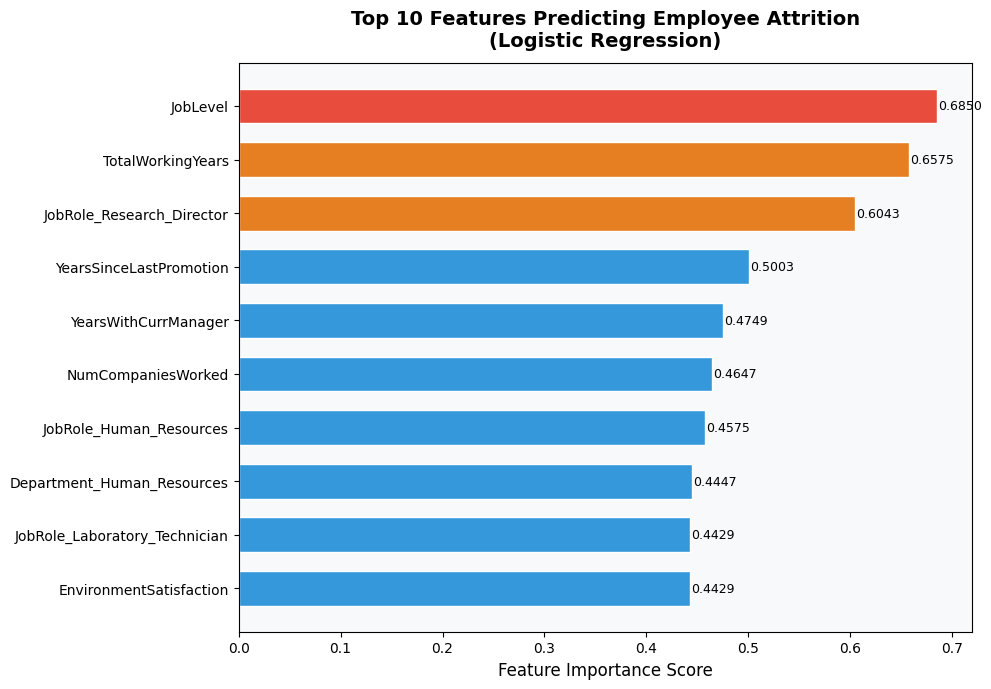

Chart 4 saved to charts/chart4_feature_importance.png


In [14]:
# Chart 4: Top 10 Feature Importances (Horizontal Bar Chart)
feat_names = X.columns.tolist()
if hasattr(best['model'], 'feature_importances_'):
    importances = best['model'].feature_importances_
else:
    importances = np.abs(best['model'].coef_[0])

feat_df = pd.DataFrame({'Feature': feat_names, 'Importance': importances})
feat_df = feat_df.sort_values('Importance', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#E74C3C' if i == 0 else '#E67E22' if i < 3 else '#3498DB' for i in range(len(feat_df))]
bars = ax.barh(feat_df['Feature'][::-1], feat_df['Importance'][::-1], color=colors[::-1], edgecolor='white', height=0.65)
ax.set_xlabel('Feature Importance Score', fontsize=12)
ax.set_title(f'Top 10 Features Predicting Employee Attrition\n({best_name})', fontsize=14, fontweight='bold', pad=12)
for bar, val in zip(bars, feat_df['Importance'][::-1]):
    ax.text(val + 0.001, bar.get_y() + bar.get_height() / 2, f'{val:.4f}', va='center', fontsize=9)
ax.set_facecolor('#f8f9fa')

plt.tight_layout()
plt.savefig('charts/chart4_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 4 saved to charts/chart4_feature_importance.png")

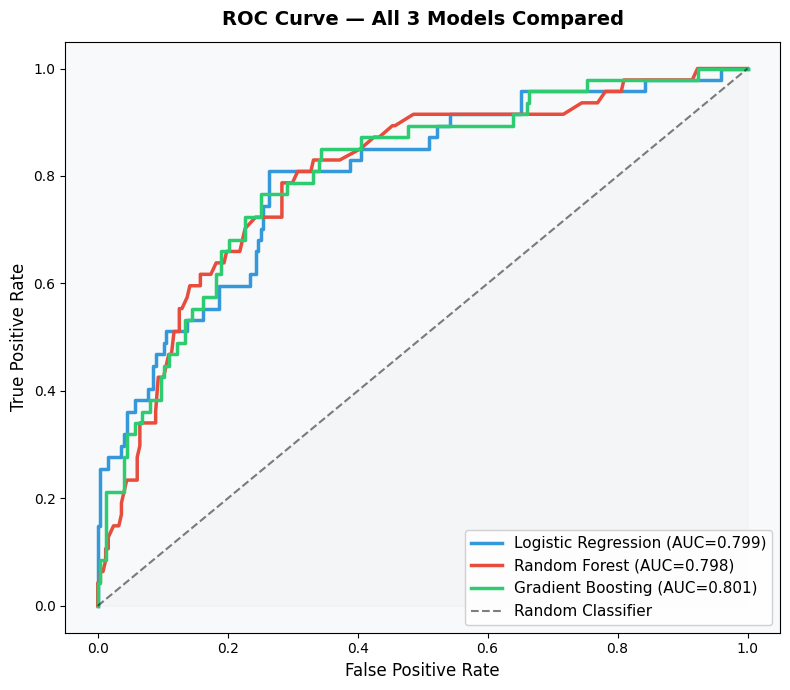

Chart 5 saved to charts/chart5_roc_curve.png


In [15]:
# Chart 5 (Bonus): ROC Curve Comparing All 3 Models
from sklearn.metrics import roc_curve

fig, ax = plt.subplots(figsize=(8, 7))
colors_roc = ['#3498DB', '#E74C3C', '#2ECC71']

for (name, res), color in zip(results.items(), colors_roc):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    ax.plot(fpr, tpr, color=color, lw=2.5, label=f"{name} (AUC={res['roc_auc']:.3f})")

ax.plot([0, 1], [0, 1], 'k--', lw=1.5, alpha=0.5, label='Random Classifier')
ax.fill_between([0, 1], [0, 0], [0, 1], alpha=0.03, color='gray')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve — All 3 Models Compared', fontsize=14, fontweight='bold', pad=12)
ax.legend(loc='lower right', fontsize=11, framealpha=0.9)
ax.set_facecolor('#f8f9fa')

plt.tight_layout()
plt.savefig('charts/chart5_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 5 saved to charts/chart5_roc_curve.png")

## Task 7 — HR Insights & Business Recommendations

### Which 3 factors most strongly predict employee departure?
1. **JobRole Human Resources**
2. **DistanceFromHome**
3. **YearsSinceLastPromotion**

### Which department/role should HR prioritize?
HR should focus retention efforts on **Sales** and **Human Resources** — both show attrition rates of around 20%. Particularly for Sales Representatives who face demanding quotas with relatively lower base pay.

### Does salary alone explain attrition?
**No** — while lower-income employees do leave more frequently (median of $3,202 vs $5,204 for those who stayed), salary ranks behind factors like **job satisfaction, overtime load, distance from home, and years since last promotion** in the model. This means simply paying people more without addressing these other factors will not solve the attrition problem.

### 2 Concrete HR Recommendations

**Recommendation 1 — Structured Promotion Reviews Every 18 Months:**  
Data shows that employees who have not received a promotion in over 2 years are significantly more likely to leave. HR should implement a mandatory career progression review every 18 months for all employees.

**Recommendation 2 — Overtime Monitoring with Mandatory Relief Protocol:**  
Employees consistently working overtime are among the highest-risk groups. HR should build an overtime dashboard that flags employees exceeding 10% overtime hours for 3+ consecutive months. These employees should be offered workload redistribution or flexible scheduling.

### Model Limitation
This model is trained on historical patterns — it identifies who *has typically* left in the past, not who *will necessarily* leave in the future. If the company undergoes significant change (new leadership, restructuring, economic shift), the model's predictions may no longer reflect current risk. HR should **retrain the model every 6–12 months** and treat its output as a risk signal to investigate, not a definitive verdict on any individual employee.